In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix

In [22]:
iris = load_iris()
X = iris.data[:, [2, 3]]  # Use petal length and petal width
y = iris.target


In [23]:
def run_experiment(n_runs=30, test_size=0.2):
    accs = []
    conf_total = np.zeros((3, 3), dtype=int)

    for _ in range(n_runs):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y
        )

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = Perceptron(
            max_iter=1000,
            eta0=0.01,
            random_state=None
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accs.append(accuracy_score(y_test, y_pred))
        conf_total += confusion_matrix(y_test, y_pred)

    return np.array(accs), conf_total

In [24]:
accs, conf_matrix = run_experiment()
mean_acc = accs.mean()
std_acc = accs.std()
print(f"Acurácia média: {mean_acc:.4f}")
print(f"Desvio padrão:  {std_acc:.4f}")
print("\nMatriz de confusão acumulada:")
print(conf_matrix)

Acurácia média: 0.8678
Desvio padrão:  0.1166

Matriz de confusão acumulada:
[[290  10   0]
 [ 55 212  33]
 [  0  21 279]]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

model = Perceptron(max_iter=1000, eta0=0.01)
model.fit(X_train, y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,0.01
,n_jobs,None
,random_state,0


In [26]:
# Malha de pontos
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

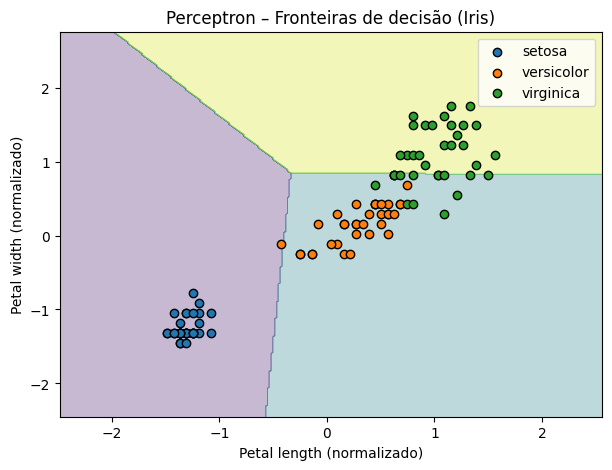

In [27]:
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3)

for class_value, color, label in zip(
    [0, 1, 2],
    ['red', 'green', 'blue'],
    iris.target_names
):
    plt.scatter(
        X_train[y_train == class_value, 0],
        X_train[y_train == class_value, 1],
        label=label,
        edgecolor='k'
    )

plt.xlabel("Petal length (normalizado)")
plt.ylabel("Petal width (normalizado)")
plt.legend()
plt.title("Perceptron – Fronteiras de decisão (Iris)")
plt.show()

In [28]:
from sklearn.linear_model import SGDClassifier
def run_adaline(n_runs=30, test_size=0.2):
    accs = []
    conf_total = np.zeros((3, 3), dtype=int)

    for _ in range(n_runs):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y
        )

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = SGDClassifier(
            loss="squared_error",   
            learning_rate="constant",
            eta0=0.01,
            max_iter=1000
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accs.append(accuracy_score(y_test, y_pred))
        conf_total += confusion_matrix(y_test, y_pred)

    return np.array(accs), conf_total

accs, conf_matrix = run_adaline()

print(f"Acurácia média: {accs.mean():.4f}")
print(f"Desvio padrão: {accs.std():.4f}")
print("\nMatriz de confusão acumulada:")
print(conf_matrix)


Acurácia média: 0.7611
Desvio padrão: 0.0584

Matriz de confusão acumulada:
[[300   0   0]
 [ 23 112 165]
 [  0  27 273]]


In [29]:
from sklearn.neural_network import MLPClassifier

def run_mlp(n_runs=30, test_size=0.2):
    accs = []
    conf_total = np.zeros((3, 3), dtype=int)

    for _ in range(n_runs):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y
        )

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = MLPClassifier(
            hidden_layer_sizes=(10,),
            activation="relu",
            max_iter=2000
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accs.append(accuracy_score(y_test, y_pred))
        conf_total += confusion_matrix(y_test, y_pred)

    return np.array(accs), conf_total

accs, conf_matrix = run_mlp()

print(f"Acurácia média: {accs.mean():.4f}")
print(f"Desvio padrão: {accs.std():.4f}")
print("\nMatriz de confusão acumulada:")
print(conf_matrix)


Acurácia média: 0.9611
Desvio padrão: 0.0311

Matriz de confusão acumulada:
[[300   0   0]
 [  0 284  16]
 [  0  19 281]]
